In [1]:
from scipy.io import loadmat, whosmat
import numpy as np
import pandas as pd
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [2]:
def read_adcirc_grd(grd_file: str):

    with open(grd_file, "r") as f:
        _header0 = f.readline()
        header1 = f.readline()
        header_nums = list(map(float, header1.split()))
        nelmts = int(header_nums[0])
        nnodes = int(header_nums[1])

        Nodes = np.loadtxt(f, max_rows=nnodes)
        Elmts = np.loadtxt(f, max_rows=nelmts) - 1
        lines = f.readlines()

    return Nodes, Elmts, lines

In [3]:
df = pd.read_csv("outputs/selected_cases_MDA.csv", header=None)
selected_cases = df.iloc[:, 0].tolist()[:3000]

In [4]:
lons = [-77.766, -76.9845, -75.36, -74.837]
lats = [33.441, 33.8928, 35.10, 36.603]
names_points = ["point_1", "point_2", "point_3", "point_4"]

In [5]:
xds_post = xr.open_dataset("outputs/Vars_postprocessed_proj.nc")

In [6]:
xds_post

<xarray.Dataset> Size: 7MB
Dimensions:   (case_num: 3000, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 24kB 464 2496 12410 8723 ... 10282 5093 2216 8976
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float32 1MB ...
    TPsmoo    (case_num, time, point) float32 1MB ...
    Windv_x   (case_num, time, point) float32 1MB ...
    Windv_y   (case_num, time, point) float32 1MB ...
    Dir_x     (case_num, time, point) float32 1MB ...
    Dir_y     (case_num, time, point) float32 1MB ...

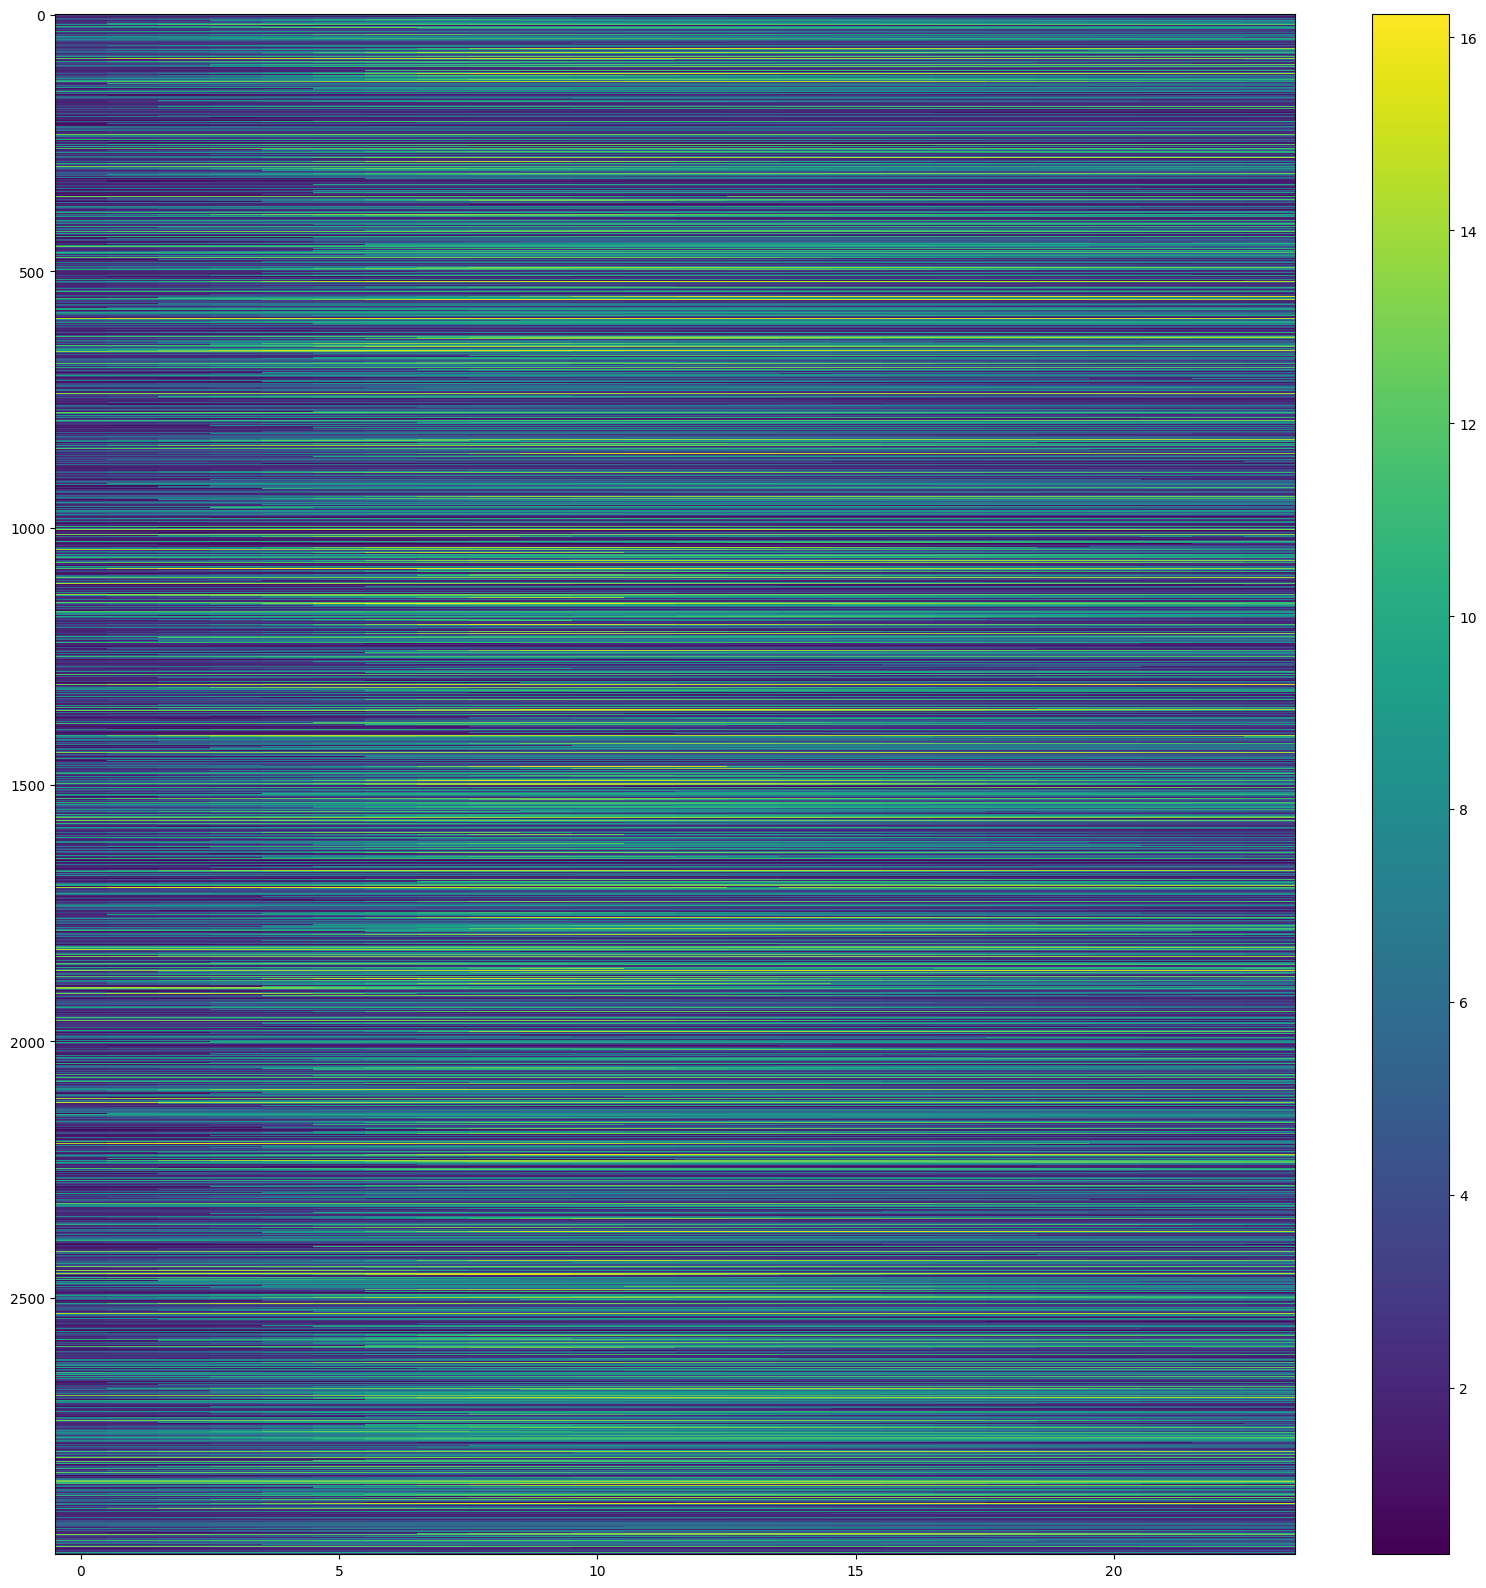

In [7]:
fig, ax = plt.subplots(figsize=(20, 20))

pm = ax.imshow(
    xds_post.TPsmoo.sel(point="point_1").values,
    aspect='auto',
    interpolation='none'
)
fig.colorbar(pm, ax=ax)

In [8]:
df_parametros = pd.read_csv("outputs/syntetic_tracks_7r_params.csv")
df_parametros_clean = df_parametros.iloc[xds_post.case_num.values].drop(columns=['date_furthest'])

,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh
0,177.719087,773.901253,48.566770,760.071837,89.739119,412.106890,1000.299621,994.470343,1003.972938,43.128626,53.152029,51.855053
1,143.132065,763.772384,77.196057,752.395017,108.099855,611.664535,1006.934131,1005.751253,1007.499586,41.702667,56.359839,73.505913
2,242.046138,764.523754,337.078755,760.723750,255.426095,550.708001,1009.992257,1008.344215,1013.131241,52.355686,52.330823,56.621322
3,200.761073,772.267422,109.908886,773.186746,218.492458,424.063107,1006.707026,1004.102245,1007.827385,15.652328,11.475800,13.395999
4,151.695460,754.535602,73.166860,761.730646,136.280703,553.340763,958.586550,953.153471,954.880882,30.233394,36.291348,60.409235
...,...,...,...,...,...,...,...,...,...,...,...,...
13179,239.226643,768.013004,337.842416,178.783764,223.955308,432.907076,1011.083223,1010.288755,1013.443706,45.280196,9.623877,26.320195
13180,237.226297,749.173529,53.615454,766.119864,60.522525,490.658479,1012.199768,1006.393286,1012.401104,25.096406,71.336059,44.782570
13181,170.842094,756.433455,51.198805,764.234725,162.697444,525.461469,977.691633,984.755140,977.284923,34.249932,49.208074,112.936411
13182,252.052355,776.409297,172.819014,464.038743,226.793577,454.642026,1013.217366,1012.250534,1013.474759,38.227003,36.932411,32.605414


In [9]:
from bluemath_tk.datamining.pca import PCA
import matplotlib.pyplot as plt


for param in xds_post.data_vars.keys():
    vars_to_drop = [k for k in xds_post.data_vars.keys() if k != param]
    xds_post_meta = xds_post.drop_vars(vars_to_drop)

    pca_output_all = PCA(n_components=0.998, # % of variance to retain
                        is_incremental=False, 
                        debug=True, );
    pca_output_all.fit_transform( 
        data=xds_post_meta, 
        vars_to_stack=list(xds_post_meta.data_vars.keys()), 
        coords_to_stack=["time", "point"],
        pca_dim_for_rows="case_num",
        
    );

    pca_output_all.save_model(f"outputs/pca_model_{param}.pkl")
    eofs = pca_output_all.eofs[param]
    pcs = pca_output_all.pcs.PCs

    n_comp = len(eofs.n_component)
    n_points = len(eofs.point)

    fig, axes = plt.subplots(
        n_comp,
        1,
        figsize=(10, 2 * n_comp),
        sharex=True,
    )

    cmap = plt.get_cmap("tab10")
    colors = cmap(np.linspace(0, 1, n_points))
    print(param)
    print(len(eofs))

    for j, point in enumerate(eofs.point.values):
        vals_point = eofs.sel(point=point)

        for i, comp in enumerate(eofs.n_component.values):
            axes[i].plot(
                vals_point.sel(n_component=comp),
                color=colors[j],
                label=f"{point}" if i == 0 else None,
                linewidth=1.5,
            )

            axes[i].set_ylabel(f"EOF {comp} (m)")
            axes[i].grid(True, alpha=0.3)

    fig.legend()

    axes[-1].set_xlabel("Index")

    fig.tight_layout(rect=[0, 0, 0.95, 1])
    fig.suptitle(f"EOFs of {param}")
    fig.savefig(f"figures/Syntesis/08_eofs_{param}.png")
    plt.close(fig)


2026-02-12 12:48:09,227 - PCA - WARNING - Using 96 out of 96 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-02-12 12:48:09,421 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


Hsig
22


2026-02-12 12:48:11,474 - PCA - WARNING - Using 96 out of 96 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-02-12 12:48:11,710 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


TPsmoo
40


2026-02-12 12:48:14,382 - PCA - WARNING - Using 96 out of 96 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-02-12 12:48:14,513 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


...

Windv_y
40


2026-02-12 12:48:20,291 - PCA - WARNING - Using 96 out of 96 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-02-12 12:48:20,779 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


Dir_x
39


2026-02-12 12:48:23,766 - PCA - WARNING - Using 96 out of 96 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-02-12 12:48:23,989 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


Dir_y
45


In [16]:
df_parametros_clean

,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh
464,191.665252,776.309373,132.360173,534.818633,146.787449,416.555073,1013.169883,1012.144171,1013.521331,23.867619,11.710237,9.302977
2496,182.933774,443.985315,80.220917,763.899719,194.037136,420.218269,1011.983739,1013.307969,983.528475,8.630645,3.134896,15.770127
12410,215.811222,688.818400,33.615197,767.412864,174.245226,284.742586,1002.746293,1013.392475,1012.606807,23.235366,7.901321,15.822753
8723,242.717383,758.833879,47.929743,394.514328,7.356092,71.576218,1013.280195,1010.457280,1013.464117,27.173404,40.519027,45.402121
6398,204.282258,776.100235,56.588622,757.175889,228.082174,675.102371,1007.218454,1008.555870,1005.527666,5.873497,8.975690,40.759687
...,...,...,...,...,...,...,...,...,...,...,...,...
2338,226.441515,777.802755,54.111825,718.384762,206.702419,168.936912,1012.243671,1011.915392,1012.388320,52.665213,60.498374,74.085922
10282,206.716862,768.260607,43.567837,737.742957,215.298131,584.456072,946.225613,939.497774,973.149466,22.967124,29.637468,70.357560
5093,135.605139,313.638671,106.869101,762.389963,152.420177,960.521769,1004.309544,1012.244657,972.342601,4.097047,10.679547,12.769779
2216,177.816770,765.999425,282.813776,763.622559,250.059677,402.396057,1005.216268,992.422436,1012.141082,41.083663,25.263251,34.942083


In [19]:
import pickle

df_parametros_reconstruct = df_parametros.drop(columns=['date_furthest'])
variables = ["Hsig", "TPsmoo", "Windv_x", "Windv_y", "Dir_x", "Dir_y"]

ds_predicted_test_all = {}

for var in variables:
    with open(f"outputs/pca_model_{var}.pkl", "rb") as f:
        pca_output_all = pickle.load(f)
    with open(f"outputs/rbf_model_{var}.pkl", "rb") as f:
        rbf_model = pickle.load(f)

    predictions = rbf_model.predict(dataset = df_parametros_reconstruct)

    ds_predicted_test = xr.Dataset(
        {"PCs": (("case_num", "n_component"), predictions.values),},
        coords={"case_num": df_parametros_reconstruct.index.values,"n_component": np.arange(predictions.shape[1])})

    ds_predicted_test_all[var] = pca_output_all.inverse_transform(ds_predicted_test)
    

INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Proposed max custom scaler for distance_entrance is lower than datapoint
INFO:RBF:Proposed min custom scaler for azimuth_exit is bigger than datapoint
INFO:RBF:Proposed max custom scaler for p_entrance_hPa is lower than datapoint
INFO:RBF:Proposed min custom scaler for p_exit_hPa is bigger than datapoint
INFO:RBF:Proposed max custom scaler for p_exit_hPa is lower than datapoint
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating target variable PC5
INFO:RBF:Interpolating target variable PC6
INFO:RBF:Interpolating target variable PC7
INFO:RBF:Interpolating target variable PC8
INFO:RBF:Interpolating target variable PC9
INFO:RBF:

In [20]:
ds_final = xr.merge(ds_predicted_test_all.values())
ds_final.to_netcdf("outputs/ds_predicted_test_all.nc")

In [21]:
ds_final

<xarray.Dataset> Size: 61MB
Dimensions:   (case_num: 13184, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 105kB 0 1 2 3 4 ... 13179 13180 13181 13182 13183
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float64 10MB 0.0137 0.01961 ... 5.681
    TPsmoo    (case_num, time, point) float64 10MB 2.488 2.266 ... 8.705 10.39
    Windv_x   (case_num, time, point) float64 10MB -0.6555 -0.6438 ... -15.55
    Windv_y   (case_num, time, point) float64 10MB -1.574 -1.703 ... -12.17
    Dir_x     (case_num, time, point) float64 10MB 0.3288 0.2817 ... -1.796e-05
    Dir_y     (case_num, time, point) float64 10MB 0.7904 0.6796 ... 1.007

In [ ]:
colors = ['b', 'g', 'r', 'k']
linestyles = ['--', ':', '-']
labels = ['Predicted PCA', 'Predicted Linear PCA', 'Original data']
rmse = []
rmse_linear = []

for i in range(len(target_test.index.values)-1):
    case_plot = target_test.index.values[i]
    fig, ax = plt.subplots(figsize=(15, 5))

    for j, point_plot in enumerate(names_points):
        hsig_pca_predicted_test_data = hsig_pca_predicted_test.sel(case_num=case_plot, point=point_plot).Hsig
        hsig_pca_predicted_test_data.plot(ax=ax, color=colors[j], linestyle=linestyles[0], label=labels[0])

        hsig_pca_predicted_linear_test_data = hsig_pca_predicted_linear_test.sel(case_num=case_plot, point=point_plot).Hsig
        hsig_pca_predicted_linear_test_data.plot(ax=ax, color=colors[j], linestyle=linestyles[1], label=labels[1])

        xds_post_data = xds_post.sel(case_num=case_plot, point=point_plot).Hsig
        xds_post_data.plot(ax=ax, color=colors[j], linestyle=linestyles[2], label=labels[2])

        rmse_u = np.mean((hsig_pca_predicted_test_data.values - xds_post_data.values)**2)
        rmse_linear_e = np.mean((hsig_pca_predicted_linear_test_data.values - xds_post_data.values)**2)

        rmse.append(rmse_u)
        rmse_linear.append(rmse_linear_e)
        
        rms_pca = np.sqrt(rmse_u)
        rms_linear = np.sqrt(rmse_linear_e)

        ax.text(0.02, 0.95 - j*0.05, 
                f"{point_plot} RMS PCA: {rms_pca:.3f} m, RMS Linear: {rms_linear:.3f} m", 
                transform=ax.transAxes, 
                fontsize=10, 
                verticalalignment='top', 
                color=colors[j])
        if j == 0:
            ax.legend()

    fig.savefig(f"figures/07_metamodel_comp/comparison_case_{case_plot}.png", dpi=150)
    plt.close()

print(f"RMS PCA mean: {np.mean(rmse)**0.5} m")
print(f"RMS Linear mean: {np.mean(rmse_linear)**0.5} m")

RMS PCA mean: 0.41555211139672676 m
RMS Linear mean: 0.4753726178591751 m


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


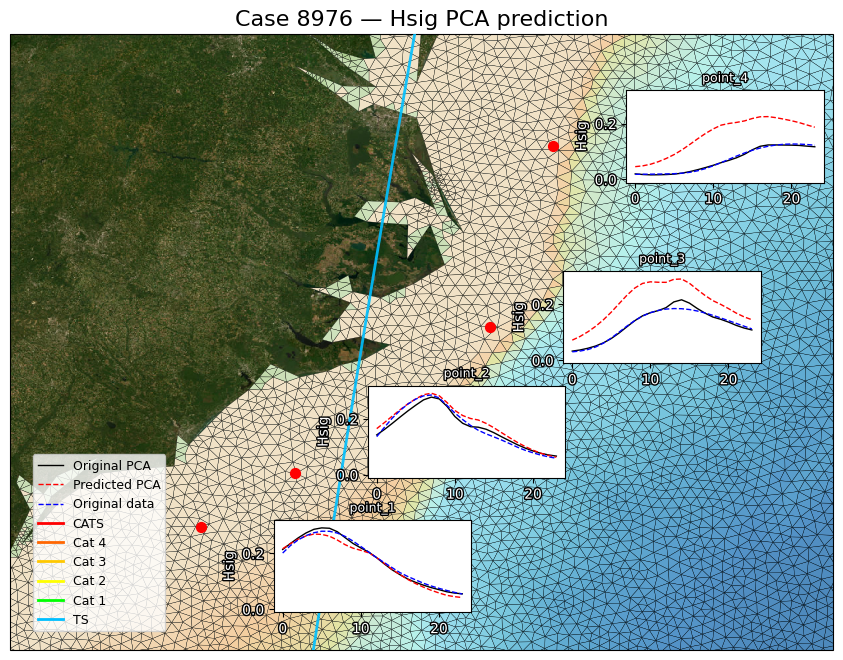

In [ ]:
plot_case(target_test.index.values[-1])

In [ ]:
# from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
# import cartopy.crs as ccrs

# plot = DefaultStaticPlotting()
# Nodes_calc, Elmts_calc, lines_calc = read_adcirc_grd("templates/fort.14")

# facecolor = np.mean(Nodes_calc[:, 3][Elmts_calc[:, 2:5].astype(int)], axis=1)

# fig, ax = plot.get_subplots(
#     subplot_kw={"projection": ccrs.PlateCarree()},
#     figsize=(12, 8),
# )

# pcl = ax.tripcolor(
#     Nodes_calc[:, 1],
#     Nodes_calc[:, 2],
#     Elmts_calc[:, 2:5],
#     facecolor,
#     edgecolors="k",
#     linewidth=0.2,
#     shading="flat",
#     cmap="terrain_r",
# )
# for lon, lat, name in zip(lons, lats, names_points):
#     ax.scatter(
#         lon,
#         lat,
#         color="red",
#         s=50,
#         transform=ccrs.PlateCarree(),
#         zorder=5,
#     )
# colorbar = fig.colorbar(pcl, ax=ax)
# colorbar.set_label("Bathymetry (m)")

# aera = [
#     -79.3521655481863,
#     -72.51257294869774,
#     32.41864762299485,
#     37.53678870673376,
# ]
# plot.plot_satellite(
#         ax=ax,
#         source="arcgis",
#         area=aera,
#     )

In [ ]:
from pyproj import Geod
from scipy.optimize import root_scalar

geod = Geod(ellps='WGS84')

def point_from_center(lat_c, lon_c, az_deg, dist_km):
    """Calcule lat/lon depuis un centre, azimut et distance."""
    lon2, lat2, _ = geod.fwd(lon_c, lat_c, az_deg, dist_km * 1000)
    return lat2, lon2


def compute_entrance_exit_azimuth_prolong(df, lat_s, lon_s, radius_km=777):
    """Calcule les azimuts d'entrée/sortie avec projection sur cercle."""
    def dist_from_site(lat, lon):
        return geod.inv(lon_s, lat_s, lon, lat)[2] / 1000
    
    lat_e, lon_e = df.iloc[0][['lat', 'lon']]
    d1 = dist_from_site(lat_e, lon_e)

    lat_x, lon_x = df.iloc[-1][['lat', 'lon']]
    dn = dist_from_site(lat_x, lon_x)
    
    return geod.inv(lon_s, lat_s, lon_e, lat_e)[0] % 360, d1, geod.inv(lon_s, lat_s, lon_x, lat_x)[0] % 360, dn


def mean_translation_velocity(df, i1, i2):
    """Vitesse de translation (km/h)."""
    lat1, lon1 = df.iloc[i1][['lat', 'lon']]
    lat2, lon2 = df.iloc[i2][['lat', 'lon']]
    dt_h = (df.index[i2] - df.index[i1]).total_seconds() / 3600
    return geod.inv(lon1, lat1, lon2, lat2)[2] / 1000 / dt_h if dt_h else np.nan


def furthest_point_from_entry_exit(df, lat_s, lon_s):
    """Point le plus éloigné de la ligne entrée-sortie."""
    if df is None or len(df) < 3:
        return None, None, None
    lon_e, lat_e = df.iloc[0][['lon', 'lat']]
    lon_x, lat_x = df.iloc[-1][['lon', 'lat']]
    dists = [geod.inv(lon_e, lat_e, r['lon'], r['lat'])[2] + 
             geod.inv(lon_x, lat_x, r['lon'], r['lat'])[2] for _, r in df.iterrows()]
    idx = df.index[dists.index(max(dists))]
    az, _, d = geod.inv(lon_s, lat_s, df.loc[idx, 'lon'], df.loc[idx, 'lat'])
    return idx, d / 1000, az % 360


def travel_time_linear_v(d_km, v1, v2):
    """Temps de parcours avec vitesse linéaire."""
    return d_km / v1 if abs(v2 - v1) < 1e-6 else (d_km / (v2 - v1)) * np.log(v2 / v1)


def solve_velocity(d, dt, v2):
    """Résout v1 sachant distance, temps et v2."""
    if dt <= 0 or d <= 0:
        return d / max(dt, 1e-6)
    def eq(v1):
        if v1 <= 0: return dt
        if abs(v2 - v1) < 1e-6: return v1 - d/dt
        return (d / (v2 - v1)) * np.log(v2 / v1) - dt
    try:
        sol = root_scalar(eq, bracket=[1e-3, 10 * v2], method='brentq')
        return sol.root if sol.converged else d / dt
    except:
        return d / dt


def interpolate_geodesic(lat1, lon1, lat2, lon2, dists_km):
    """Interpole le long d'une géodésique."""
    total_m = geod.inv(lon1, lat1, lon2, lat2)[2]
    az = geod.inv(lon1, lat1, lon2, lat2)[0]
    frac = np.clip(dists_km / (total_m / 1000), 0, 1)
    pts = [geod.fwd(lon1, lat1, az, f * total_m) for f in frac]
    return np.array([p[1] for p in pts]), np.array([p[0] for p in pts])


def integrate_distance(v1, v2, total_h, dt=1.0):
    """Intègre distance avec vitesse linéaire."""
    t = np.arange(0, total_h + dt, dt)
    v = np.linspace(v1, v2, len(t))
    return t, v, np.cumsum(v * dt) - v[0] * dt

def get_category_color(p_hPa):
    """Retourne la couleur et le nom de catégorie selon la pression."""
    if p_hPa < 920:
        return '#FF0000', 'CATS'      # Rouge vif
    elif p_hPa < 944:
        return '#FF6600', 'Cat 4'      # Orange foncé
    elif p_hPa < 964:
        return '#FFC800', 'Cat 3'      # Orange/Jaune
    elif p_hPa < 979:
        return '#FFFF00', 'Cat 2'      # Jaune
    elif p_hPa < 1000:
        return '#00FF00', 'Cat 1'      # Vert
    else:
        return '#00BFFF', 'TS'         # Bleu clair
    
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import matplotlib.patheffects as pe
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
from bluemath_tk.core.plotting.colors import hex_colors_land, hex_colors_water
from bluemath_tk.core.plotting.utils import join_colormaps
from matplotlib.lines import Line2D

lon_site = -75.5730
lat_site = 36.0050

def plot_case(case_plot):
    plt.close("all")
    
    legend_handles = [
        Line2D([0], [0], color="k", lw=1, label="Original PCA"),
        Line2D([0], [0], color="r", lw=1, ls="--", label="Predicted PCA"),
        Line2D([0], [0], color="b", lw=1, ls="--", label="Original data"),
        Line2D([0], [0], color="#FF0000", lw=2, label="CATS"),
        Line2D([0], [0], color="#FF6600", lw=2, label="Cat 4"),
        Line2D([0], [0], color="#FFC800", lw=2, label="Cat 3"),
        Line2D([0], [0], color="#FFFF00", lw=2, label="Cat 2"),
        Line2D([0], [0], color="#00FF00", lw=2, label="Cat 1"),
        Line2D([0], [0], color="#00BFFF", lw=2, label="TS"),
    ]
    
    proj = ccrs.PlateCarree()
    
    plot = DefaultStaticPlotting()
    Nodes_calc, Elmts_calc, _ = read_adcirc_grd("templates/fort.14")
    
    facecolor = np.mean(
        Nodes_calc[:, 3][Elmts_calc[:, 2:5].astype(int)],
        axis=1,
    )
    
    vmin = np.nanmin(-facecolor)
    vmax = np.nanmax(-facecolor)
    
    cmap_name = f"raster_cmap_{case_plot}"
    
    try:
        if cmap_name in plt.colormaps():
            plt.colormaps().unregister(cmap_name)
    except:
        pass
    
    cmap, norm = join_colormaps(
        cmap1=hex_colors_water,
        cmap2=hex_colors_land,
        value_range1=(vmin, 0.0),
        value_range2=(0.0, vmax),
        name=cmap_name,
    )
    
    fig, ax = plot.get_subplots(
        subplot_kw={"projection": proj},
        figsize=(12, 8),
    )
    
    ax.set_title(
        f"Case {case_plot} — Hsig PCA prediction",
        fontsize=16,
    )
    
    ax.tripcolor(
        Nodes_calc[:, 1],
        Nodes_calc[:, 2],
        Elmts_calc[:, 2:5],
        -facecolor,
        edgecolors="k",
        linewidth=0.2,
        shading="flat",
        cmap=cmap,
        norm=norm,
    )
    
    for lon, lat in zip(lons, lats):
        ax.scatter(
            lon,
            lat,
            color="red",
            s=50,
            transform=proj,
            zorder=5,
        )
    
    area = [
        -79.3521655481863,
        -72.51257294869774,
        32.41864762299485,
        37.53678870673376,
    ]
    
    plot.plot_satellite(
        ax=ax,
        source="arcgis",
        area=area,
    )
    ax.set_extent(area, crs=proj)
    
    ax.legend(
        handles=legend_handles,
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        framealpha=0.8,
        fontsize=9,
    )
    
    for lon, lat, point_name in zip(lons, lats, names_points):
        if point_name == "point_1":
            y_moins = 0.15
        elif point_name == "point_2":
            y_moins = 0.02
        else:
            y_moins = 0.07
    
        pca_ori_case = hsig_pca_original.sel(case_num=case_plot)
        pca_pred_case = hsig_pca_predicted_test.sel(case_num=case_plot)
    
        pca_ori_max = pca_ori_case.Hsig.max().values
        pca_pred_max = pca_pred_case.Hsig.max().values
        pca_ori_min = pca_ori_case.Hsig.min().values
        pca_pred_min = pca_pred_case.Hsig.min().values
    
        y_max = np.max([pca_ori_max, pca_pred_max])
        y_min = np.min([pca_ori_min, pca_pred_min])
        
        da_orig = pca_ori_case.sel(point=point_name).Hsig
        da_pred = pca_pred_case.sel(point=point_name).Hsig
        da_or = xds_post.sel(case_num=case_plot, point=point_name).Hsig
        
        x_disp, y_disp = ax.transData.transform(
            proj.transform_point(lon, lat, proj)
        )
        x_ax, y_ax = ax.transAxes.inverted().transform((x_disp, y_disp))
        
        ax_inset = inset_axes(
            ax,
            width="24%",
            height="15%",
            bbox_to_anchor=(x_ax + 0.08, y_ax - y_moins, 1, 1),
            bbox_transform=ax.transAxes,
            loc="lower left",
            borderpad=0.5,
        )
        
        da_orig.plot(
            ax=ax_inset,
            color="k",
            lw=1,
            add_legend=False,
        )
        da_pred.plot(
            ax=ax_inset,
            color="r",
            lw=1,
            ls="--",
            add_legend=False,
        )

        da_or.plot(
            ax=ax_inset,
            color="b",
            lw=1,
            ls="--",
            add_legend=False,
        )
    
        ax_inset.set_xlabel("")
        ax_inset.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))
    
        stroke = [
            pe.Stroke(linewidth=2, foreground="black"),
            pe.Normal(),
        ]
    
        title = ax_inset.set_title(
            f"{point_name}",
            color="white",
            fontsize=9,
        )
        title.set_path_effects(stroke)
    
        ylabel = ax_inset.yaxis.get_label()
        ylabel.set_color("white")
        ylabel.set_fontsize(10)
        ylabel.set_path_effects(stroke)
    
        for label in ax_inset.get_xticklabels() + ax_inset.get_yticklabels():
            label.set_color("white")
            label.set_fontsize(10)
            label.set_path_effects(stroke)
    
        ax_inset.set_facecolor("white")
    
    p = df_parametros_clean.loc[case_plot]
    
    v_entr = p["vmean_entrance_kmh"]
    v_fur  = p["vmean_furthest_kmh"]
    v_exit = p["vmean_exit_kmh"]
    
    if v_entr > 0 and v_fur > 0 and v_exit > 0:
        lat_f, lon_f = point_from_center(
            lat_site, lon_site,
            p["azimuth_furthest"],
            p["distance_furthest_km"],
        )
    
        lat_e, lon_e = point_from_center(
            lat_site, lon_site,
            p["azimuth_entrance"],
            p["distance_entrance"],
        )
    
        lat_x, lon_x = point_from_center(
            lat_site, lon_site,
            p["azimuth_exit"],
            p["distance_exit"],
        )
        
        d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
        d_fur_to_exit  = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000
    
        dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
        dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)
    
        if not np.isnan(dt1) and not np.isnan(dt2):
            t1, v1, d1 = integrate_distance(v_fur, v_entr, dt1)
            t1, v1, d1 = t1[::-1], v1[::-1], d1[-1] - d1[::-1]
            lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1)
    
            t2, v2, d2 = integrate_distance(v_fur, v_exit, dt2)
            lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2)
    
            lats_track = np.concatenate([lat1, lat2[1:]])
            lons_track = np.concatenate([lon1, lon2[1:]])
            
            pmin = min(
                p["p_entrance_hPa"],
                p["p_furthest_hPa"],
                p["p_exit_hPa"],
            )
    
            color, cat_name = get_category_color(pmin)
            
            ax.plot(
                lons_track,
                lats_track,
                color=color,
                lw=2.0,
                alpha=0.9,
                transform=proj,
                zorder=6,
                label=f"Synthetic track ({cat_name})",
            )
            ax.scatter(
                [lon_e, lon_f, lon_x],
                [lat_e, lat_f, lat_x],
                color=color,
                s=40,
                edgecolor="k",
                transform=proj,
                zorder=7,
            )